# CFRNet

This notebook starts the CFRNet implementation using the same binary treatment definition, train/test split, and preprocessing used in the TARNet and ATARNet notebooks.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
seed = 123
split_seed = 42
batch_size = 256


random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

torch.set_num_threads(1)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
data_path = Path("../data/raw/hillstrom_email.csv")
df = pd.read_csv(data_path)

print("Rows:", len(df))
print("Columns:", df.shape[1])
df.head()

Rows: 64000
Columns: 12


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [4]:
df.groupby("segment")["visit"].agg(customers="size", visit_rate="mean")

,customers,visit_rate
segment,,
Mens E-Mail,21307,0.182757
No E-Mail,21306,0.106167
Womens E-Mail,21387,0.151400


In [5]:
numerical_columns = ["recency", "history", "mens", "womens"]
categorical_columns = ["history_segment", "zip_code", "newbie", "channel"]
treatment_column = "treatment"
outcome_column = "visit"

In [6]:
# Match treatment definition used by the baselines and other notebooks.
df[treatment_column] = (df["segment"] != "No E-Mail").astype(int)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=split_seed,
    stratify=df[treatment_column],
)

train_df = train_df.copy()
test_df = test_df.copy()

print("Training rows:", len(train_df))
print("Testing rows: ", len(test_df))

Training rows: 51200
Testing rows:  12800


In [7]:
split_summary = []
for split_name, split_df in [("train", train_df), ("test", test_df)]:
    grouped = (
        split_df.groupby(treatment_column)[outcome_column]
        .agg(["size", "mean"])
        .reset_index()
    )
    grouped["split"] = split_name
    grouped["group"] = grouped[treatment_column].map({0: "No E-Mail", 1: "Any E-Mail"})
    grouped = grouped.rename(columns={"size": "customers", "mean": "visit_rate"})
    split_summary.append(grouped[["split", "group", "customers", "visit_rate"]])

pd.concat(split_summary, ignore_index=True)

,split,group,customers,visit_rate
0,train,No E-Mail,17045,0.105837
1,train,Any E-Mail,34155,0.166916
2,test,No E-Mail,4261,0.107487
3,test,Any E-Mail,8539,0.167584


In [8]:
scaler = StandardScaler()
scaler.fit(train_df[numerical_columns])

category_mappings = {}
categorical_cardinalities = []

for column in categorical_columns:
    categories = train_df[column].unique().tolist()
    category_mappings[column] = {
        category: index for index, category in enumerate(categories)
    }
    categorical_cardinalities.append(len(categories))

print("Categorical cardinalities:", categorical_cardinalities)

Categorical cardinalities: [7, 3, 2, 3]


In [9]:
def make_tensors(frame):
    numeric = scaler.transform(frame[numerical_columns])

    categorical_parts = []
    for column in categorical_columns:
        ids = frame[column].map(category_mappings[column]).to_numpy()
        if pd.isna(ids).any():
            raise ValueError(f"Unseen category found in {column}")
        categorical_parts.append(ids)

    categorical = np.column_stack(categorical_parts)
    treatment = frame[treatment_column].to_numpy()
    outcome = frame[outcome_column].to_numpy()

    return TensorDataset(
        torch.tensor(numeric, dtype=torch.float32),
        torch.tensor(categorical, dtype=torch.long),
        torch.tensor(treatment, dtype=torch.float32),
        torch.tensor(outcome, dtype=torch.float32),
    )


train_dataset = make_tensors(train_df)
test_dataset = make_tensors(test_df)

generator = torch.Generator()
generator.manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

next(iter(train_loader))[0].shape

torch.Size([256, 4])

In [10]:
print("Training samples", len(train_dataset))
print("Testing samples", len(test_dataset))

Training samples 51200
Testing samples 12800


## 4. CFRNet architecture

This CFRNet keeps the same encoder style and fixed training schedule used in the TARNet notebook. The main addition is an imbalance penalty on the shared representation so treated and control customers are encouraged to occupy similar latent regions before the separate outcome heads are applied.

In [11]:
class FeatureEncoder(nn.Module):
    def __init__(self, num_numeric, category_sizes, embedding_dim=4):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [nn.Embedding(size, embedding_dim) for size in category_sizes]
        )
        self.output_dim = num_numeric + len(category_sizes) * embedding_dim

    def forward(self, numeric, categorical):
        embedded = [
            embedding(categorical[:, index])
            for index, embedding in enumerate(self.embeddings)
        ]
        return torch.cat([numeric, *embedded], dim=1)


class ResidualBlock(nn.Module):
    def __init__(self, width, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(width),
            nn.Linear(width, width * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(width * 2, width),
        )

    def forward(self, inputs):
        return inputs + self.block(inputs)


class OutcomeHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, representation):
        return self.network(representation)


class CFRNet(nn.Module):
    def __init__(
        self,
        num_numeric,
        category_sizes,
        embedding_dim=4,
        shared_width=128,
        representation_dim=64,
        head_width=32,
        dropout=0.15,
    ):
        super().__init__()
        self.encoder = FeatureEncoder(
            num_numeric=num_numeric,
            category_sizes=category_sizes,
            embedding_dim=embedding_dim,
        )
        self.shared_network = nn.Sequential(
            nn.Linear(self.encoder.output_dim, shared_width),
            nn.GELU(),
            ResidualBlock(shared_width, dropout),
            ResidualBlock(shared_width, dropout),
            nn.LayerNorm(shared_width),
            nn.Linear(shared_width, representation_dim),
            nn.GELU(),
        )
        self.control_head = OutcomeHead(representation_dim, head_width, dropout)
        self.treatment_head = OutcomeHead(representation_dim, head_width, dropout)

    def forward(self, numeric, categorical):
        features = self.encoder(numeric, categorical)
        representation = self.shared_network(features)
        control_logit = self.control_head(representation)
        treatment_logit = self.treatment_head(representation)
        return {
            "control_logit": control_logit,
            "treatment_logit": treatment_logit,
            "representation": representation,
        }


def linear_mmd_penalty(control_representation, treatment_representation):
    if len(control_representation) < 2 or len(treatment_representation) < 2:
        return control_representation.new_tensor(0.0)

    control_mean = control_representation.mean(dim=0)
    treatment_mean = treatment_representation.mean(dim=0)

    return torch.sum((control_mean - treatment_mean) ** 2)


def cfrnet_loss(outputs, treatment, outcome, imbalance_weight):
    treatment = treatment.view(-1)
    outcome = outcome.view(-1)

    control_logit = outputs["control_logit"].view(-1)
    treatment_logit = outputs["treatment_logit"].view(-1)
    representation = outputs["representation"]

    control_loss = nn.functional.binary_cross_entropy_with_logits(
        control_logit,
        outcome,
        reduction="none",
    )
    treatment_loss = nn.functional.binary_cross_entropy_with_logits(
        treatment_logit,
        outcome,
        reduction="none",
    )
    factual_loss = ((1.0 - treatment) * control_loss + treatment * treatment_loss).mean()

    control_mask = treatment < 0.5
    treatment_mask = treatment >= 0.5
    imbalance_loss = linear_mmd_penalty(
        representation[control_mask],
        representation[treatment_mask],
    )

    total_loss = factual_loss + imbalance_weight * imbalance_loss
    return {
        "total": total_loss,
        "factual": factual_loss,
        "imbalance": imbalance_loss,
    }

In [12]:
model = CFRNet(
    num_numeric=len(numerical_columns),
    category_sizes=categorical_cardinalities,
).to(device)

number_of_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

sample_numeric, sample_categorical, sample_treatment, sample_outcome = next(iter(train_loader))
with torch.no_grad():
    sample_outputs = model(
        sample_numeric[:8].to(device),
        sample_categorical[:8].to(device),
    )

print(model)
print(f"\nTrainable parameters: {number_of_parameters:,}")
print("Control output shape:", sample_outputs["control_logit"].shape)
print("Treatment output shape:", sample_outputs["treatment_logit"].shape)
print("Representation shape:", sample_outputs["representation"].shape)

CFRNet(
  (encoder): FeatureEncoder(
    (embeddings): ModuleList(
      (0): Embedding(7, 4)
      (1): Embedding(3, 4)
      (2): Embedding(2, 4)
      (3): Embedding(3, 4)
    )
  )
  (shared_network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=128, out_features=256, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=256, out_features=128, bias=True)
      )
    )
    (3): ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=128, out_features=256, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=256, out_features=128, bias=True)
      )
  

## 5. Train the model

For a fair first comparison, CFRNet uses the same outer split and fixed training schedule as TARNet and ATARNet: Adam with learning rate `0.0005`, batch size `256`, and `20` epochs. The only additional training term is the CFR imbalance penalty, which is given a fixed weight `alpha = 1.0` here.

In [13]:
imbalance_weight = 1.0
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

number_of_epochs = 20
train_total_losses = []
train_factual_losses = []
train_imbalance_losses = []

for epoch in range(number_of_epochs):
    model.train()
    total_loss_sum = 0.0
    factual_loss_sum = 0.0
    imbalance_loss_sum = 0.0

    for numeric, categorical, treatment, outcome in train_loader:
        numeric = numeric.to(device)
        categorical = categorical.to(device)
        treatment = treatment.to(device)
        outcome = outcome.to(device)

        optimizer.zero_grad()
        outputs = model(numeric, categorical)
        losses = cfrnet_loss(
            outputs=outputs,
            treatment=treatment,
            outcome=outcome,
            imbalance_weight=imbalance_weight,
        )
        losses["total"].backward()
        optimizer.step()

        batch_size_actual = len(outcome)
        total_loss_sum += losses["total"].item() * batch_size_actual
        factual_loss_sum += losses["factual"].item() * batch_size_actual
        imbalance_loss_sum += losses["imbalance"].item() * batch_size_actual

    average_total_loss = total_loss_sum / len(train_dataset)
    average_factual_loss = factual_loss_sum / len(train_dataset)
    average_imbalance_loss = imbalance_loss_sum / len(train_dataset)

    train_total_losses.append(average_total_loss)
    train_factual_losses.append(average_factual_loss)
    train_imbalance_losses.append(average_imbalance_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Total: {average_total_loss:.4f} | "
        f"Factual: {average_factual_loss:.4f} | "
        f"Imbalance: {average_imbalance_loss:.4f}"
    )

Epoch 01 | Total: 0.4460 | Factual: 0.4371 | Imbalance: 0.0089
Epoch 02 | Total: 0.4136 | Factual: 0.4105 | Imbalance: 0.0031
Epoch 03 | Total: 0.4095 | Factual: 0.4063 | Imbalance: 0.0031
Epoch 04 | Total: 0.4080 | Factual: 0.4053 | Imbalance: 0.0026
Epoch 05 | Total: 0.4065 | Factual: 0.4040 | Imbalance: 0.0025
Epoch 06 | Total: 0.4060 | Factual: 0.4041 | Imbalance: 0.0019
Epoch 07 | Total: 0.4048 | Factual: 0.4032 | Imbalance: 0.0017
Epoch 08 | Total: 0.4050 | Factual: 0.4034 | Imbalance: 0.0016
Epoch 09 | Total: 0.4051 | Factual: 0.4035 | Imbalance: 0.0016
Epoch 10 | Total: 0.4038 | Factual: 0.4023 | Imbalance: 0.0015
Epoch 11 | Total: 0.4037 | Factual: 0.4024 | Imbalance: 0.0012
Epoch 12 | Total: 0.4041 | Factual: 0.4029 | Imbalance: 0.0013
Epoch 13 | Total: 0.4029 | Factual: 0.4017 | Imbalance: 0.0012
Epoch 14 | Total: 0.4030 | Factual: 0.4019 | Imbalance: 0.0011
Epoch 15 | Total: 0.4031 | Factual: 0.4019 | Imbalance: 0.0012
Epoch 16 | Total: 0.4022 | Factual: 0.4012 | Imbalance:

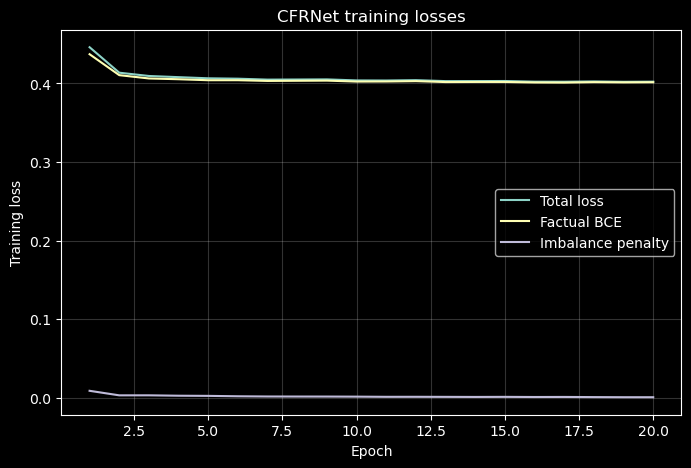

In [14]:
plt.figure(figsize=(8, 5))
epochs = range(1, number_of_epochs + 1)
plt.plot(epochs, train_total_losses, label="Total loss")
plt.plot(epochs, train_factual_losses, label="Factual BCE")
plt.plot(epochs, train_imbalance_losses, label="Imbalance penalty")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("CFRNet training losses")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## 6. Generate potential outcomes

Each customer receives two predicted visit probabilities: one under no email and one under any email. Their difference is the estimated uplift.

In [15]:
def predict_potential_outcomes(model, data_loader):
    model.eval()
    control_probabilities = []
    treatment_probabilities = []
    treatments = []
    outcomes = []

    with torch.no_grad():
        for numeric, categorical, treatment, outcome in data_loader:
            numeric = numeric.to(device)
            categorical = categorical.to(device)

            outputs = model(numeric, categorical)
            control_probabilities.append(torch.sigmoid(outputs["control_logit"]).cpu())
            treatment_probabilities.append(torch.sigmoid(outputs["treatment_logit"]).cpu())
            treatments.append(treatment.cpu())
            outcomes.append(outcome.cpu())

    potential_outcomes = torch.cat(
        [
            torch.cat(control_probabilities, dim=0),
            torch.cat(treatment_probabilities, dim=0),
        ],
        dim=1,
    ).numpy()

    return (
        potential_outcomes,
        torch.cat(treatments, dim=0).numpy().reshape(-1),
        torch.cat(outcomes, dim=0).numpy().reshape(-1),
    )


potential_outcomes, test_treatment, test_outcome = predict_potential_outcomes(
    model,
    test_loader,
)

factual_probability = potential_outcomes[
    np.arange(len(test_treatment)),
    test_treatment.astype(int),
]

results = test_df.reset_index(drop=True).copy()
results["pred_control"] = potential_outcomes[:, 0]
results["pred_treatment"] = potential_outcomes[:, 1]
results["predicted_uplift"] = results["pred_treatment"] - results["pred_control"]
results["factual_probability"] = factual_probability

results.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment,pred_control,pred_treatment,predicted_uplift,factual_probability
0,6,5) $500 - $750,508.62,0,1,Surburban,1,Web,Mens E-Mail,1,0,0.0,1,0.080764,0.143482,0.062718,0.143482
1,10,4) $350 - $500,460.26,1,1,Urban,0,Phone,Womens E-Mail,0,0,0.0,1,0.210045,0.291393,0.081349,0.291393
2,10,1) $0 - $100,35.05,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0,1,0.065894,0.118330,0.052436,0.118330
3,7,2) $100 - $200,141.74,1,0,Urban,0,Phone,Mens E-Mail,0,0,0.0,1,0.062637,0.114194,0.051557,0.114194
4,7,1) $0 - $100,31.30,0,1,Rural,1,Phone,Mens E-Mail,0,0,0.0,1,0.060535,0.116115,0.055580,0.116115


In [16]:
calibration_rows = []
for treatment_id, group_name in [(0, "No E-Mail"), (1, "Any E-Mail")]:
    mask = test_treatment.astype(int) == treatment_id
    calibration_rows.append(
        {
            "group": group_name,
            "customers": int(mask.sum()),
            "observed_visit_rate": float(test_outcome[mask].mean()),
            "average_factual_prediction": float(factual_probability[mask].mean()),
        }
    )

pd.DataFrame(calibration_rows)

,group,customers,observed_visit_rate,average_factual_prediction
0,No E-Mail,4261,0.107487,0.107494
1,Any E-Mail,8539,0.167584,0.171112


In [17]:
control_rate = results.loc[results[treatment_column] == 0, outcome_column].mean()
treatment_rate = results.loc[results[treatment_column] == 1, outcome_column].mean()
randomized_test_ate = treatment_rate - control_rate

pd.DataFrame(
    {
        "randomized_test_ATE": [randomized_test_ate],
        "average_predicted_uplift": [results["predicted_uplift"].mean()],
        "median_predicted_uplift": [results["predicted_uplift"].median()],
        "minimum_predicted_uplift": [results["predicted_uplift"].min()],
        "maximum_predicted_uplift": [results["predicted_uplift"].max()],
    }
)

,randomized_test_ATE,average_predicted_uplift,median_predicted_uplift,minimum_predicted_uplift,maximum_predicted_uplift
0,0.060098,0.061976,0.063996,0.029505,0.095322


## 7. Evaluate factual predictions

These metrics evaluate how well the model predicts the observed outcome under the treatment each customer actually received.

In [18]:
factual_metrics = pd.DataFrame(
    {
        "test_log_loss": [
            log_loss(test_outcome, np.clip(factual_probability, 1e-6, 1 - 1e-6))
        ],
        "test_roc_auc": [roc_auc_score(test_outcome, factual_probability)],
    }
)

factual_metrics

,test_log_loss,test_roc_auc
0,0.401959,0.64334


## 8. Uplift evaluation

Following the TARNet notebook, use an inverse-propensity-weighted cumulative gain curve to summarize how well the ranking captures incremental visits.

In [19]:
def uplift_curve(frame):
    ranked = frame.sort_values("predicted_uplift", ascending=False).reset_index(drop=True)

    treated = ranked[treatment_column].to_numpy(dtype=float)
    outcome = ranked[outcome_column].to_numpy(dtype=float)
    propensity = treated.mean()

    # Random treatment assignment supports this IPW estimate of incremental visits.
    contribution = outcome * (
        treated / propensity - (1 - treated) / (1 - propensity)
    )
    cumulative_gain = np.concatenate([[0.0], np.cumsum(contribution) / len(ranked)])
    fraction_targeted = np.linspace(0, 1, len(cumulative_gain))
    random_gain = fraction_targeted * cumulative_gain[-1]

    return {
        "ranked": ranked,
        "contribution": contribution,
        "fraction_targeted": fraction_targeted,
        "cumulative_gain": cumulative_gain,
        "random_gain": random_gain,
        "AUUC": np.trapz(cumulative_gain, fraction_targeted),
        "Qini_coefficient": np.trapz(cumulative_gain - random_gain, fraction_targeted),
    }


curve_results = uplift_curve(results)

uplift_metrics = pd.DataFrame(
    {
        "AUUC": [curve_results["AUUC"]],
        "Qini_coefficient": [curve_results["Qini_coefficient"]],
    }
)

uplift_metrics

,AUUC,Qini_coefficient
0,0.033082,0.003033


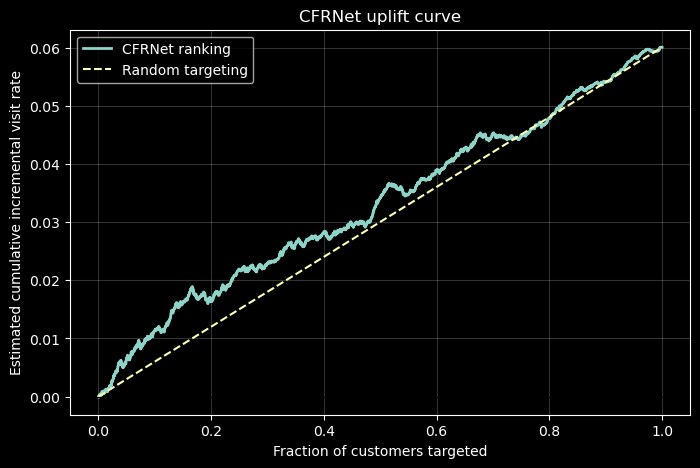

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(
    curve_results["fraction_targeted"],
    curve_results["cumulative_gain"],
    label="CFRNet ranking",
    linewidth=2,
)
plt.plot(
    curve_results["fraction_targeted"],
    curve_results["random_gain"],
    label="Random targeting",
    linestyle="--",
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Fraction of customers targeted")
plt.ylabel("Estimated cumulative incremental visit rate")
plt.title("CFRNet uplift curve")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [21]:
targeting_rows = []
contribution = curve_results["contribution"]

for fraction in [0.05, 0.10, 0.20]:
    number_targeted = int(np.ceil(len(contribution) * fraction))
    estimated_uplift = contribution[:number_targeted].mean()
    targeting_rows.append(
        {
            "target_fraction": fraction,
            "customers_in_evaluation": number_targeted,
            "estimated_visit_uplift": estimated_uplift,
            "incremental_visits_per_1000": 1000 * estimated_uplift,
        }
    )

targeting_results = pd.DataFrame(targeting_rows)
targeting_results

,target_fraction,customers_in_evaluation,estimated_visit_uplift,incremental_visits_per_1000
0,0.05,640,0.128447,128.446921
1,0.10,1280,0.114380,114.379737
2,0.20,2560,0.082200,82.200258
